# Pulsos con simulación

In [1]:
# from oficial python
import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch
from matplotlib import cm
import matplotlib as mpl
from qutip import basis, tensor
import time
from sklearn.model_selection import train_test_split
import pennylane as qml
import os
import pandas as pd

# own modules:
from dll.spin_procesor_modificated import Quantum_Spin_Proces
from dll.main_fun import make_IRIS_v2, pulse_x_with_noise, pulse_x, pulse_z
from dll. baseline_dru_v2 import Modelo_DRU
from dll.models import qcircuit_1_qubit_mixed, qcircuit_2_qubit_mixed, qcircuit_4_qubit_mixed
from dll.cost_functions import fidelity_cost
from dll.gate_procesor_modificated import CompositeGateProcessor

In [2]:
def calculate_fidelity(state_base_line, state_spins):
  # convert spin to dm
  nf, nc = state_spins.shape
  if nc == 1:
    dm_spin = state_spins @ state_spins.conj().T
  # calculare fidelity:
  F  = qml.math.fidelity(state_base_line, dm_spin)
  return F
  

In [4]:
def make_total_pulse(B0_pulses):
  # Convertir el array a tipo float para poder asignar NaN
  B0_pulses = B0_pulses.astype(float)

  # Crear un vector complementario donde los ceros se reemplazan por unos
  B0_complement = np.where(B0_pulses == 0, np.min(B0_pulses), B0_pulses)

  # Crear una máscara para los valores que son cero en el vector original
  mask = B0_pulses == 0

  # Crear una copia del vector original para graficar los valores reales mayores que cero
  B0_pulses_real = np.copy(B0_pulses)
  B0_pulses_real[mask] = np.nan  # Reemplazar los ceros con NaN para no plotearlos

  # Crear una copia del vector complementario para graficar los valores complementados
  B0_pulses_complement = np.copy(B0_complement)
  B0_pulses_complement[~mask] = np.nan  # Reemplazar los valores no complementados con NaN
  
  return B0_complement, B0_pulses_complement

In [ ]:
def plot_pulses_v33(self, verbose=1, key_show='all', entangl=False, 
                   fontsize_axes=12, fontsize_title=14, fontsize_text=11):
    # Tomar todos los pulsos:
    resultado = self.pulse_type
    # Definir el tiempo global de simulación:
    glob_time = self.global_time
    
    # Por cada pulso...
    for key in resultado:
        # Identificar su tipo:
        list_pulses = resultado[key]
        
        # Caso pulso unitario:
        if list_pulses[0]['Type_pulse'] == 'Unitary':
            print(key)
            global_time_sim = np.linspace(0, glob_time, 1000)  # Tiempo total de simulación
            B1_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso Bx
            B0_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso B0
            
            for dict_pulse in list_pulses:
                # B0 results
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                B0_i = dict_pulse['B0'] * pulse_z(global_time_sim, args2)
                # Se guarda reiterativamente los pulsos cuadrados:
                B0_pulses += np.array(B0_i)
                
                # B1 results
                if self.tf_noise == True:
                    dv = self.noise_std/abs(dict_pulse['B1']) if dict_pulse['B1'] != 0 else 0
                else:
                    dv = 0
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f'], "std_noise": dv}
                B1_i = dict_pulse['B1'] * pulse_x_with_noise(global_time_sim, args2)
                B1_pulses += np.array(B1_i)
            
            # Plot para B0
            #B0_pulses_blue, B0_pulses_red = make_total_pulse(np.abs(B0_pulses))
            B0_pulses_blue, B0_pulses_red = make_total_pulse(B0_pulses)
            B0_pulses_blue[0] = B0_pulses_blue[-1] = 0
            B0_pulses_red[0] = B0_pulses_red[-1] = 0
            
            plt.figure(figsize=(8, 3))
            # plt.plot(global_time_sim * 1e9, np.abs(B0_pulses), linewidth=0.5, color='darkblue')
            plt.plot(global_time_sim * 1e9, B0_pulses, linewidth=0.5, color='darkblue')  
            plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')
            plt.plot(global_time_sim * 1e9, B0_pulses_red, 'r-', label=r'Virtual $I$ gate')
            plt.title("Pulse sequence for Bz", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bz [T]", fontsize=fontsize_axes)
            plt.grid()
            if self.N_qubits > 1:
                plt.legend()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B0_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

            # Plot para B1
            plt.figure(figsize=(8, 3))
            plt.plot(global_time_sim * 1e9, B1_pulses, linewidth=1.7, color='darkblue')
            plt.title("Pulse sequence for Bx", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bx [T]", fontsize=fontsize_axes)
            plt.grid()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B1_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

        elif list_pulses[0]['Type_pulse'] == "Two_Qubits":
            global_time_sim = np.linspace(0, glob_time, 100000)
            fig, ax = plt.subplots(figsize=(8, 3))
            
            swap_color = 'darkblue'
            sqrt_swap_color = 'darkgreen'
            swap_plotted = False
            sqrt_swap_plotted = False
            
            for th, dict_pulse in enumerate(list_pulses):
                J_pulses = np.zeros(len(global_time_sim))
                t_i = dict_pulse['t_i']  # Tiempo inicial
                t_f = dict_pulse['t_f']  # Tiempo final
                J = dict_pulse['J']  # Amplitud de J
                duration = t_f - t_i  # Duración del pulso
                Swap_time = np.pi / J  # Tiempo esperado para SWAP
                sqrt_Swap_time = np.pi / (2 * J)  # Tiempo esperado para sqrt SWAP
                
                label = "SWAP" if abs(duration - Swap_time) < 1e-13 else r"$\sqrt{SWAP}$" if abs(duration - sqrt_Swap_time) < 1e-13 else "Unknown"
                color = swap_color if label == "SWAP" else sqrt_swap_color if label == r"$\sqrt{SWAP}$" else 'gray'
                
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                hbar = 6.582e-13
                J_i = hbar * dict_pulse['J'] * pulse_x(global_time_sim, args2)
                J_pulses += np.array(J_i)
                
                t_center = (t_f + t_i) / 2
                y_text = hbar * dict_pulse['J'] * 1.05
                ax.text((t_center * 1e9) * np.random.uniform(0.99, 1.00), y_text,
                        label, horizontalalignment='center',
                        verticalalignment='bottom', rotation=90, fontsize=fontsize_text)
                
                if label == "SWAP" and not swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label='SWAP')
                    swap_plotted = True
                elif label == r"$\sqrt{SWAP}$" and not sqrt_swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label=r'$\sqrt{SWAP}$')
                    sqrt_swap_plotted = True
                else:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color)
            
            ax.set_xlabel("time [ns]", fontsize=fontsize_axes)
            ax.set_ylabel("J [meV]", fontsize=fontsize_axes)
            ax.set_ylim([0, (np.max(J_pulses)) * 1.30])
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            plt.grid()
            ax.legend()
            
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"J_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re  # Necesario para extraer índices de los keys (ej: "q_0" -> 0)

def plot_pulses_v33_2(self, verbose=1, key_show='all', entangl=False, 
                   fontsize_axes=12, fontsize_title=14, fontsize_text=11):
    """
    Grafica la secuencia de pulsos y retorna las estructuras de datos
    compatibles con la simulación por trotterización.
    """
    # Tomar todos los pulsos:
    resultado = self.pulse_type
    # Definir el tiempo global de simulación:
    glob_time = self.global_time
    
    # --- Estructuras para el return compatible con la simulación ---
    # Inicializamos lista de listas para B (un sub-lista por qubit)
    # Asumimos que self.N_qubits está definido correctamente.
    B_pulse_intervals_per_site = [[] for _ in range(self.N_qubits)]
    
    # Inicializamos diccionario para J (clave: tupla (i,j), valor: lista de intervalos)
    # Usamos diccionario porque J depende del par específico.
    J_pulse_intervals_dict = {} 
    # ---------------------------------------------------------------

    # Por cada pulso...
    for key in resultado:
        # Identificar su tipo:
        list_pulses = resultado[key]
        
        # Extraer índices numéricos del key (ej: "q_1" -> [1], "q0_q1" -> [0, 1])
        indices = [int(s) for s in re.findall(r'\d+', str(key))]
        
        # Caso pulso unitario (Single Qubit):
        if list_pulses[0]['Type_pulse'] == 'Unitary':
            if verbose > 0: print(f"Processing Unitary key: {key}")
            
            # Asumimos que si es unitario, hay un solo índice en el key
            qubit_idx = indices[0] if indices else 0
            
            global_time_sim = np.linspace(0, glob_time, 1000)  # Tiempo total de simulación
            B1_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso Bx
            B0_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso B0
            
            for dict_pulse in list_pulses:
                # --- Recolección de datos para Simulación (B fields) ---
                t_i, t_f = dict_pulse['t_i'], dict_pulse['t_f']
                # B1 es campo en X, B0 es campo en Z (incluye Virtual I/Z)
                bx_amp = dict_pulse.get('B1', 0.0)
                bz_amp = dict_pulse.get('B0', 0.0)
                
                # Solo agregamos si el intervalo es válido y hay amplitud
                if t_f > t_i:
                    # Formato: (t_start, t_end, (Bx, By, Bz))
                    # Nota: Las I_VIRTUALS suelen ser rotaciones Z, aquí incluidas en B0 (Bz)
                    B_pulse_intervals_per_site[qubit_idx].append(
                        (t_i, t_f, (bx_amp, 0.0, bz_amp))
                    )
                # ------------------------------------------------------

                # B0 results (Plotting logic)
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                # Nota: pulse_z debe estar definido en el contexto global o self
                B0_i = dict_pulse['B0'] * pulse_z(global_time_sim, args2)
                B0_pulses += np.array(B0_i)
                
                # B1 results (Plotting logic)
                if self.tf_noise == True:
                    dv = self.noise_std/abs(dict_pulse['B1']) if dict_pulse['B1'] != 0 else 0
                else:
                    dv = 0
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f'], "std_noise": dv}
                # Nota: pulse_x_with_noise debe estar definido
                B1_i = dict_pulse['B1'] * pulse_x_with_noise(global_time_sim, args2)
                B1_pulses += np.array(B1_i)
            
            # Plot para B0
            # make_total_pulse debe estar definido
            B0_pulses_blue, B0_pulses_red = make_total_pulse(B0_pulses)
            B0_pulses_blue[0] = B0_pulses_blue[-1] = 0
            B0_pulses_red[0] = B0_pulses_red[-1] = 0
            
            plt.figure(figsize=(8, 3))
            plt.plot(global_time_sim * 1e9, B0_pulses, linewidth=0.5, color='darkblue')  
            plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')
            plt.plot(global_time_sim * 1e9, B0_pulses_red, 'r-', label=r'Virtual $I$ gate')
            plt.title(f"Pulse sequence for Bz (Qubit {qubit_idx})", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bz [T]", fontsize=fontsize_axes)
            plt.grid()
            if self.N_qubits > 1:
                plt.legend()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B0_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            # Crear directorio si no existe para evitar error
            os.makedirs(os.path.dirname(path_to_save_img), exist_ok=True)
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

            # Plot para B1
            plt.figure(figsize=(8, 3))
            plt.plot(global_time_sim * 1e9, B1_pulses, linewidth=1.7, color='darkblue')
            plt.title(f"Pulse sequence for Bx (Qubit {qubit_idx})", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bx [T]", fontsize=fontsize_axes)
            plt.grid()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B1_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

        elif list_pulses[0]['Type_pulse'] == "Two_Qubits":
            # Identificar par de qubits
            if len(indices) >= 2:
                pair_key = tuple(sorted(indices[:2])) # (min, max) para consistencia
            else:
                pair_key = (0, 1) # Default fallback

            global_time_sim = np.linspace(0, glob_time, 100000)
            fig, ax = plt.subplots(figsize=(8, 3))
            
            swap_color = 'darkblue'
            sqrt_swap_color = 'darkgreen'
            swap_plotted = False
            sqrt_swap_plotted = False
            
            # Inicializar lista para este par en el diccionario de retorno
            if pair_key not in J_pulse_intervals_dict:
                J_pulse_intervals_dict[pair_key] = []

            for th, dict_pulse in enumerate(list_pulses):
                J_pulses = np.zeros(len(global_time_sim))
                t_i = dict_pulse['t_i']  # Tiempo inicial
                t_f = dict_pulse['t_f']  # Tiempo final
                J = dict_pulse['J']  # Amplitud de J
                
                # --- Recolección de datos para Simulación (J coupling) ---
                if t_f > t_i:
                    # Formato: (t_start, t_end, amplitude)
                    J_pulse_intervals_dict[pair_key].append((t_i, t_f, J))
                # ---------------------------------------------------------

                duration = t_f - t_i  # Duración del pulso
                Swap_time = np.pi / J if J != 0 else np.inf
                sqrt_Swap_time = np.pi / (2 * J) if J != 0 else np.inf
                
                label = "SWAP" if abs(duration - Swap_time) < 1e-13 else r"$\sqrt{SWAP}$" if abs(duration - sqrt_Swap_time) < 1e-13 else "Unknown"
                color = swap_color if label == "SWAP" else sqrt_swap_color if label == r"$\sqrt{SWAP}$" else 'gray'
                
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                hbar = 6.582e-13
                # Nota: pulse_x debe estar definido
                J_i = hbar * dict_pulse['J'] * pulse_x(global_time_sim, args2)
                J_pulses += np.array(J_i)
                
                t_center = (t_f + t_i) / 2
                y_text = hbar * dict_pulse['J'] * 1.05
                ax.text((t_center * 1e9) * np.random.uniform(0.99, 1.00), y_text,
                        label, horizontalalignment='center',
                        verticalalignment='bottom', rotation=90, fontsize=fontsize_text)
                
                if label == "SWAP" and not swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label='SWAP')
                    swap_plotted = True
                elif label == r"$\sqrt{SWAP}$" and not sqrt_swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label=r'$\sqrt{SWAP}$')
                    sqrt_swap_plotted = True
                else:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color)
            
            ax.set_xlabel("time [ns]", fontsize=fontsize_axes)
            ax.set_ylabel("J [meV]", fontsize=fontsize_axes)
            # Evitar error si J_pulses está vacío o es todo ceros
            max_J = np.max(J_pulses) if len(J_pulses) > 0 else 1.0
            ax.set_ylim([0, max_J * 1.30])
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            plt.grid()
            ax.legend()
            
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"J_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            os.makedirs(os.path.dirname(path_to_save_img), exist_ok=True)
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

    # Retornar los intervalos listos para la función de simulación
    # B_pulse_intervals_per_site: Lista de listas (índice = qubit)
    # J_pulse_intervals_dict: Diccionario {(q_i, q_j): [(t0, t1, amp), ...]}
    return B_pulse_intervals_per_site, J_pulse_intervals_dict


In [ ]:
# Pulsos para 1qubit:
X, y =  make_IRIS_v2(3,3)

model = Modelo_DRU(qcircuit_1_qubit_mixed, fidelity_cost,
                        epochs = 5, n_clases = 3, n_qubits = 1,
                        features = 3, num_layers = 10, alpha_noise = 0.0, val_prc = 0.2,
                        save_process = False, save_w_states = False)

# splita data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# get optimized parameters
paramters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=100,
                                     N_qubits = 1,
                                     tf_noise = False,
                                     noise_std = 0.0000, save_pulses= True,
                                     J = 1.52e11 )

state_dru = dru_circuit.qcircuit_DRU_1_Qubit(paramters_1q,
                                             model.X_val[1],
                                             bias=bias_1q)

# plot
plot_pulses_v33_2(dru_circuit, fontsize_axes=17, fontsize_title=24, fontsize_text=9)

Epoch: 100%|██████████| 5/5 [00:22<00:00,  4.55s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Processing Unitary key: 0


C:\Users\User\AppData\Local\Temp\ipykernel_2580\546584353.py:86: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')


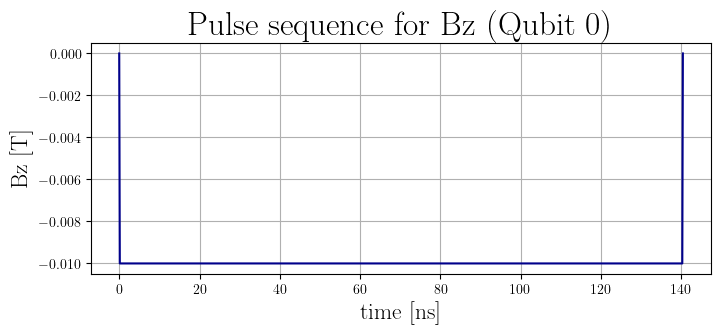

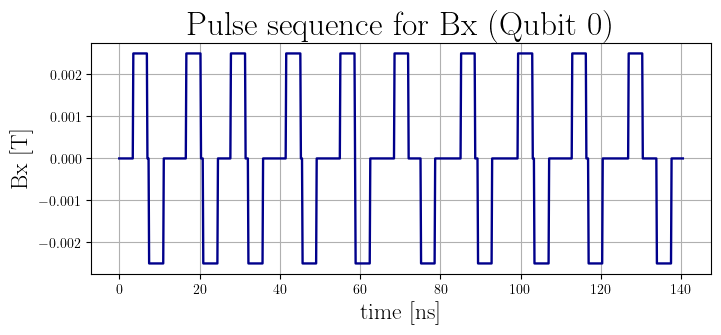

In [11]:
Bp, Jp = plot_pulses_v33_2(dru_circuit, fontsize_axes=17, fontsize_title=24, fontsize_text=9)

In [12]:
Bp, Jp

([[(0, 3.4435534211043172e-09, (0, 0.0, -0.01)),
   (3.4435534211043172e-09, 7.0135450729109e-09, (0.0025, 0.0, -0.01)),
   (7.0135450729109e-09, 7.408925128941957e-09, (0, 0.0, -0.01)),
   (7.408925128941957e-09, 1.0978916780748541e-08, (-0.0025, 0.0, -0.01)),
   (1.0978916780748541e-08, 1.3163173171222285e-08, (0, 0.0, -0.01)),
   (1.3163173171222285e-08, 1.6690435376359002e-08, (0, 0.0, -0.01)),
   (1.6690435376359002e-08, 2.0260427028165584e-08, (0.0025, 0.0, -0.01)),
   (2.0260427028165584e-08, 2.089413321150435e-08, (0, 0.0, -0.01)),
   (2.089413321150435e-08, 2.4464124863310932e-08, (-0.0025, 0.0, -0.01)),
   (2.4464124863310932e-08, 2.772972290402588e-08, (0, 0.0, -0.01)),
   (2.772972290402588e-08, 2.77783838828876e-08, (0, 0.0, -0.01)),
   (2.77783838828876e-08, 3.134837553469418e-08, (0.0025, 0.0, -0.01)),
   (3.134837553469418e-08, 3.213352521197648e-08, (0, 0.0, -0.01)),
   (3.213352521197648e-08, 3.570351686378306e-08, (-0.0025, 0.0, -0.01)),
   (3.570351686378306e-08, 3.

In [13]:
# 2 qubits con entrelazamiento:
X, y =  make_IRIS_v2(3,3)

tf_entanglement = True

model = Modelo_DRU(qcircuit_2_qubit_mixed, fidelity_cost,
                        epochs = 2, n_clases = 3, n_qubits = 2,
                        features = 3, num_layers = 4, alpha_noise = 0.0, val_prc = 0.2,
                        save_process = False, save_w_states = True,
                        entanglement = tf_entanglement )

# splita data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# get optimized parameters
paramters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=1000,
                                     N_qubits = 2,
                                     tf_noise = False,
                                     noise_std = 0.0000,
                                     ket_dru_0 = tensor(basis(2, 0),basis(2, 0)),
                                     save_pulses= True,
                                     J = 1.52e11)

state_dru = dru_circuit.qcircuit_DRU_2_Qubit(paramters_1q,
                                             model.X_val[1],
                                             bias=bias_1q,
                                             entanglement = tf_entanglement)


Epoch: 100%|██████████| 2/2 [00:08<00:00,  4.02s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Processing Unitary key: 0


C:\Users\User\AppData\Local\Temp\ipykernel_2580\546584353.py:86: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')


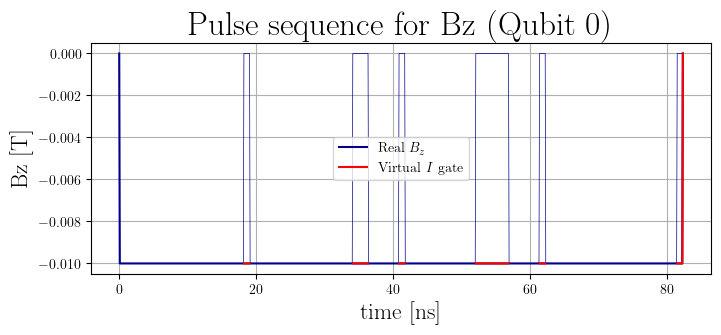

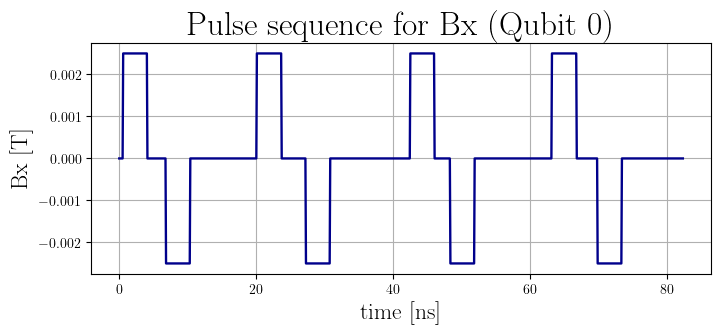

Processing Unitary key: 1


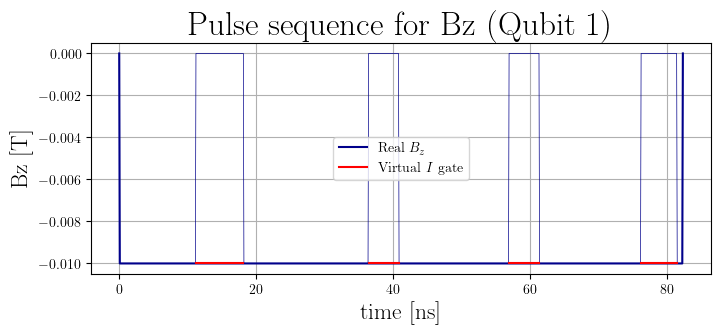

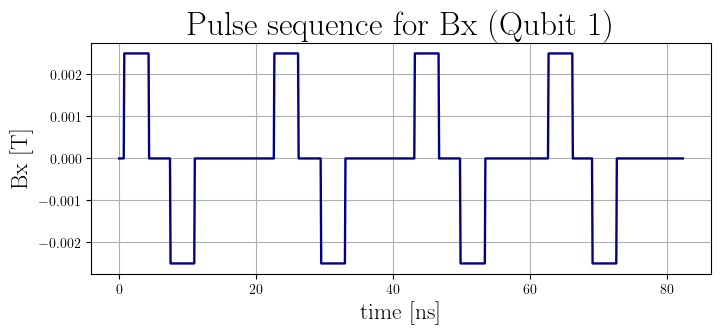

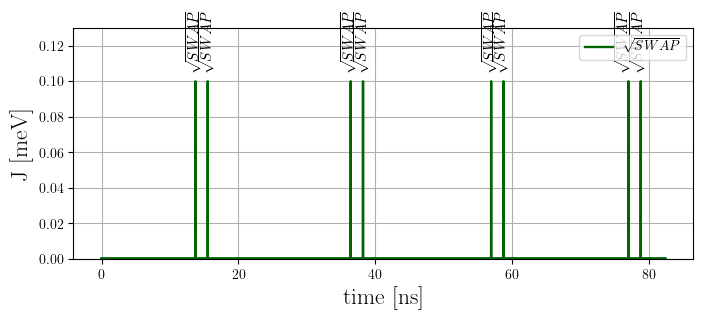

In [14]:
Bp2, Jp2 = plot_pulses_v33_2(dru_circuit, entangl=tf_entanglement, fontsize_axes=17, fontsize_title=24)

In [15]:
Bp2, Jp2

([[(0, 5.251026977983963e-10, (0, 0.0, -0.01)),
   (5.251026977983963e-10, 4.09509434960498e-09, (0.0025, 0.0, -0.01)),
   (4.09509434960498e-09, 6.804657466184362e-09, (0, 0.0, -0.01)),
   (6.804657466184362e-09, 1.0374649117990946e-08, (-0.0025, 0.0, -0.01)),
   (1.0374649117990946e-08, 1.3706868147325899e-08, (0, 0.0, -0.01)),
   (1.3717202333686392e-08, 1.5502198159589685e-08, (0, 0.0, -0.01)),
   (1.5512532345950177e-08, 1.8190026084805115e-08, (0, 0.0, -0.01)),
   (1.9082523997756762e-08, 2.0102599165466264e-08, (0, 0.0, -0.01)),
   (2.0102599165466264e-08, 2.3672590817272846e-08, (0.0025, 0.0, -0.01)),
   (2.3672590817272846e-08, 2.719741867782225e-08, (0, 0.0, -0.01)),
   (2.719741867782225e-08, 3.076741032962883e-08, (-0.0025, 0.0, -0.01)),
   (3.076741032962883e-08, 3.405057486508209e-08, (0, 0.0, -0.01)),
   (3.6400606892134536e-08, 3.818560271803783e-08, (0, 0.0, -0.01)),
   (3.8195936904398326e-08, 4.087343064325326e-08, (0, 0.0, -0.01)),
   (4.176592855620491e-08, 4.24506

# Pulsos con trotterización

In [ ]:
# trotter_vs_exact_time_dependent_fixed.py
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from scipy.linalg import expm

# -----------------------
# Parámetros físicos & sistema
# -----------------------
N = 4                    # número de spins
J_base = 1.0             # escala de acoplamiento
g_L = 1.0                # Landé g-factor
mu_B = 1.0               # Bohr magneton (escala)
total_time = 12.0
n_trotter_steps = 80     # número de pasos Trotter (coarse)
# dt_trot se calcula más abajo desde n_trotter_steps

# dispositivo PennyLane (simulador statevector) para trotter
dev = qml.device("default.qubit", wires=N)

# -----------------------
# Pulsos cuadrados: utilidad para definir señales en el tiempo
# -----------------------
def square_pulse(t, intervals):
    """
    intervals: lista de (t_start, t_end, amplitude)
    devuelve la suma de amplitudes activas en tiempo t
    """
    val = 0.0
    for (t0, t1, amp) in intervals:
        if (t >= t0) and (t < t1):
            val += amp
    return val

# -----------------------
# Definición de pulsos (ejemplo)
# -----------------------
# --- J(t): apagado (sin interacción entre spins)
J_pulse_intervals = [
    (0.0, 12.0, 0.0)
]

# --- Campos locales: pulso en X positivo y luego negativo en todos los sitios
B_pulse_intervals_per_site = [
    [(2.0, 2.4, (3.0, 0.0, 0.0)),   # campo Bx positivo corto
     (7.0, 10.0, (-4.0, 0.0, 0.0))],  # campo Bx negativo más largo
] * N

edge_list = [(i, i+1) for i in range(N-1)]

def J_ij_at_time(i, j, t):
    amp = square_pulse(t, J_pulse_intervals)
    return J_base * amp

def B_i_at_time(i, t):
    intervals = B_pulse_intervals_per_site[i] if i < len(B_pulse_intervals_per_site) else []
    Bx = 0.0; By = 0.0; Bz = 0.0
    for (t0, t1, vec) in intervals:
        if (t >= t0) and (t < t1):
            bx, by, bz = vec
            Bx += bx; By += by; Bz += bz
    return np.array([Bx, By, Bz], dtype=float)

# -----------------------
# Utilidades para construir Hamiltoniano matricial (exacta)
# -----------------------
# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
si = np.eye(2, dtype=complex)

def kron_n(op_list):
    out = op_list[0]
    for op in op_list[1:]:
        out = np.kron(out, op)
    return out

def build_H_matrix_time(t):
    """
    Construye la matriz del Hamiltoniano H(t) = sum_{<i,j>} J_ij(t) S_i·S_j - gL muB sum_i B_i(t)·S_i
    con S = 1/2 sigma.
    """
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    # término interacción S_i·S_j = 1/4 (σxσx + σyσy + σzσz)
    for (i, j) in edge_list:
        Jij = J_ij_at_time(i, j, t)
        if abs(Jij) < 1e-12:
            continue
        for op in (sx, sy, sz):
            ops = [si] * N
            ops[i] = op
            ops[j] = op
            H += (-Jij * 0.25) * kron_n(ops)

    # término Zeeman local: - g_L mu_B B_i · S_i  with S_i = sigma/2
    for i in range(N):
        Bx, By, Bz = B_i_at_time(i, t)
        if abs(Bx) > 1e-12:
            ops = [si] * N
            ops[i] = sx
            H += (-g_L * mu_B * Bx * 0.5) * kron_n(ops)
        if abs(By) > 1e-12:
            ops = [si] * N
            ops[i] = sy
            H += (-g_L * mu_B * By * 0.5) * kron_n(ops)
        if abs(Bz) > 1e-12:
            ops = [si] * N
            ops[i] = sz
            H += (-g_L * mu_B * Bz * 0.5) * kron_n(ops)

    return H

# -----------------------
# Implementación de Trotter (primer orden) en PennyLane
# -----------------------
def apply_two_body_interaction(Jij, dt_local, i, j):
    theta = Jij * dt_local / 2.0
    qml.IsingXX(theta, wires=[i, j])
    qml.IsingYY(theta, wires=[i, j])
    qml.IsingZZ(theta, wires=[i, j])

def apply_local_zeeman(Bvec, dt_local, i, gL=g_L, muB=mu_B):
    Bx, By, Bz = Bvec
    if abs(Bx) > 0:
        qml.RX(-gL * muB * Bx * dt_local, wires=i)
    if abs(By) > 0:
        qml.RY(-gL * muB * By * dt_local, wires=i)
    if abs(Bz) > 0:
        qml.RZ(-gL * muB * Bz * dt_local, wires=i)

@qml.qnode(dev)
def trotter_evolution(n_steps, scheme="first"):
    # Estado inicial: todos down |1>
    for w in range(N):
        qml.PauliX(wires=w)

    dt_trot_local = total_time / n_trotter_steps
    for k in range(n_steps):
        t = (k + 0.5) * dt_trot_local
        # interacciones
        for (i, j) in edge_list:
            Jij = J_ij_at_time(i, j, t)
            if abs(Jij) < 1e-12:
                continue
            apply_two_body_interaction(Jij, dt_trot_local, i, j)
        # Zeeman local
        for i in range(N):
            Bvec = B_i_at_time(i, t)
            if np.allclose(Bvec, 0.0):
                continue
            apply_local_zeeman(Bvec, dt_trot_local, i)

    return [qml.expval(qml.PauliZ(i)) for i in range(N)]

# -----------------------
# Estado inicial (vector) para evolución exacta
# -----------------------
def initial_down_state(N):
    v = np.array([0,1], dtype=complex)   # |1> per qubit (spin down)
    psi = v
    for _ in range(N-1):
        psi = np.kron(psi, v)
    return psi

def local_magnetizations_from_state(psi):
    """Devuelve vector de <Z_j> para el estado psi (matriz completa)."""
    res = np.zeros(N, dtype=float)
    for j in range(N):
        ops = [np.eye(2, dtype=complex)] * N
        ops[j] = sz
        Zj = kron_n(ops)
        res[j] = np.vdot(psi, Zj @ psi).real
    return res

# -----------------------
# Integración exacta en pasos (time-ordered exponential por pasos)
# -----------------------
n_exact_substeps = 100             # subpasos por paso trotter (ajustable)
n_exact_steps = n_trotter_steps * n_exact_substeps
dt_exact = total_time / n_exact_steps
dt_trot = total_time / n_trotter_steps

# tiempos a muestrear para graficar (coinciden con los pasos Trotter)
times_trot = np.linspace(0.0, total_time, n_trotter_steps + 1)

times_exact = np.linspace(0.0, total_time, n_exact_steps + 1)

# --- Calcular pulsos (para plotting)
J_vals = np.array([J_ij_at_time(0, 1, t) for t in times_trot])
Bx_vals = np.zeros((N, len(times_trot)))
for idx, t in enumerate(times_trot):
    for i in range(N):
        Bvec = B_i_at_time(i, t)
        Bx_vals[i, idx] = Bvec[0]

# --- Evolución exacta (alta resolución) muestreada cada paso Trotter
psi_exact = initial_down_state(N)
M_t_exact = [np.mean(local_magnetizations_from_state(psi_exact))]  # lista iniciada en t=0
times_exact_sampled = [0.0]

for k in range(1, n_exact_steps + 1):
    t_mid = (k - 0.5) * dt_exact
    H_mid = build_H_matrix_time(t_mid)
    U = expm(-1j * H_mid * dt_exact)
    psi_exact = U @ psi_exact
    t_curr = k * dt_exact # nuevo
    M_t_exact.append(np.mean(local_magnetizations_from_state(psi_exact))) # nuevo
    times_exact_sampled.append(t_curr) # nuevo
    #if k % n_exact_substeps == 0:
    #    M_t_exact.append(np.mean(local_magnetizations_from_state(psi_exact)))

# --- Evolución trotter (coarse)
psi0 = initial_down_state(N)
M_t_trotter = [np.mean(local_magnetizations_from_state(psi0))]  # t=0

print("Comenzando bucle temporal: se llamará al qnode trotter para cada k y se integrará la evolución exacta por pasos")
for k in range(1, n_trotter_steps + 1):
    # Trotter: ejecutamos qnode con k pasos
    vals = trotter_evolution(k, scheme="first")
    mz_trot = np.mean([float(v) for v in vals])
    M_t_trotter.append(mz_trot)
    if (k % 10) == 0:
        print(f" step {k}/{n_trotter_steps}: t={(k*dt_trot):.3f}  M_trot={mz_trot:.4f}")

# --- Convertir listas a arrays (ahora que ya no usamos append)
M_t_exact = np.array(M_t_exact)
times_exact_sampled = np.array(times_exact_sampled)

M_t_trotter = np.array(M_t_trotter)

# -----------------------
# Graficar: pulsos vs magnetización comparación
# -----------------------
fig, (ax_pulses, ax_mag) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                         gridspec_kw={'height_ratios': [1, 1.1]})

# Pulsos: J(t)
ax_pulses.plot(times_trot, J_vals, label='J(t) (global)', color='tab:gray', linewidth=2)

# Pulsos: Bx por sitio
colors = plt.cm.viridis(np.linspace(0, 1, N))
for i in range(N):
    ax_pulses.plot(times_trot, Bx_vals[i], '--', label=f'Bx site {i}', color=colors[i])

ax_pulses.set_ylabel('Pulse amplitude')
ax_pulses.set_title('Pulsos en tiempo: J(t) y Bx^{(i)}(t)')
ax_pulses.legend(loc='upper right', fontsize='small', ncol=2)
ax_pulses.grid(True)

# Magnetización: comparar exact vs trotter
ax_mag.plot(times_exact_sampled, M_t_exact, '-', color='k', lw=1.5, label='exact (fine Δt, muestreada)')
ax_mag.plot(times_trot, M_t_trotter, 'o--', color='tab:red', label='trotter (coarse Δt)')
ax_mag.set_xlabel('t')
ax_mag.set_ylabel('M(t) = (1/N) Σ ⟨Z_j⟩')
ax_mag.set_title('Magnetización total (Exacta vs Trotter)')
ax_mag.grid(True)
ax_mag.legend()

plt.tight_layout()
plt.show()


# Pipeline integrado

In [4]:
# from oficial python
import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch
from matplotlib import cm
import matplotlib as mpl
from qutip import basis, tensor
import time
from sklearn.model_selection import train_test_split
import pennylane as qml
import os
import pandas as pd

# own modules:
from dll.spin_procesor_modificated import Quantum_Spin_Proces
from dll.main_fun import make_IRIS_v2, pulse_x_with_noise, pulse_x, pulse_z
from dll. baseline_dru_v2 import Modelo_DRU
from dll.models import qcircuit_1_qubit_mixed, qcircuit_2_qubit_mixed, qcircuit_4_qubit_mixed
from dll.cost_functions import fidelity_cost
from dll.gate_procesor_modificated import CompositeGateProcessor

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNCIONES AUXILIARES
# ==========================================

def make_total_pulse(values):
    """
    Separa el pulso en parte Real (activa) y parte Virtual (gaps/ceros).
    Útil para visualización diferenciada.
    """
    values = np.array(values, dtype=float)
    # Máscara: True si el valor es 0 (Virtual/Identity)
    mask = np.isclose(values, 0.0, atol=1e-12)
    
    # Parte Real: Los ceros se vuelven NaN para no ser graficados
    real_part = np.copy(values)
    real_part[mask] = np.nan 
    
    # Parte Virtual: Los valores activos se vuelven NaN
    # Usamos 0.0 explícito para graficar la línea de "espera"
    virtual_part = np.copy(values)
    virtual_part[~mask] = np.nan 
    
    return real_part, virtual_part

def _intervals_to_dense(intervals, total_time, num_points=1000):
    """
    Convierte lista de intervalos en arrays densos para facilitar el plotting
    estilo analógico si fuera necesario.
    """
    t_dense = np.linspace(0, total_time, num_points)
    y_dense = np.zeros_like(t_dense)
    
    for (t0, t1, amp, _) in intervals:
        mask = (t_dense >= t0) & (t_dense < t1)
        y_dense[mask] += amp
        
    return t_dense, y_dense

# ==========================================
# 2. MOTOR DE EXTRACCIÓN (Exportación)
# ==========================================

def extract_pulses_data(processor_obj):
    """
    Extrae los pulsos del objeto procesador y los organiza en una estructura
    estándar para simulación y graficado.
    
    Retorna:
        pulse_data (dict): {
            'sites': { qubit_id: {'Bx':[], 'By':[], 'Bz':[]} },
            'edges': { (q_i, q_j): {'J':[]} },
            'total_time': float
        }
    """
    pulse_data = {
        'sites': {},
        'edges': {},
        'total_time': processor_obj.global_time
    }

    # Inicializar estructura para N qubits
    for i in range(processor_obj.N_qubits):
        pulse_data['sites'][i] = {'Bx': [], 'By': [], 'Bz': []}

    raw_data = processor_obj.pulse_type
    
    # Iterar sobre las claves del diccionario de pulsos original
    # Asumimos que raw_data puede tener claves arbitrarias o índices.
    for key in raw_data:
        list_pulses = raw_data[key]
        if not list_pulses: continue

        type_pulse = list_pulses[0].get('Type_pulse', 'Unitary')

        if type_pulse == 'Unitary':
            # Intentar deducir el índice del qubit. 
            # Si key es un int, usalo. Si N=1, es 0. 
            # En sistemas complejos, el dict_pulse debería tener 'qubit_index'.
            # Aquí generalizamos asumiendo sequential mapping si key es string.
            try:
                qubit_idx = int(key) if isinstance(key, int) or key.isdigit() else 0
            except:
                qubit_idx = 0
            
            # Asegurar que el índice existe
            if qubit_idx not in pulse_data['sites']:
                pulse_data['sites'][qubit_idx] = {'Bx': [], 'By': [], 'Bz': []}

            for p in list_pulses:
                t_i, t_f = p['t_i'], p['t_f']
                # Extraer amplitudes (Soporte para By si existiera en el futuro)
                b0_amp = p.get('B0', 0.0) # Bz
                b1_amp = p.get('B1', 0.0) # Bx (Transversal)
                b2_amp = p.get('B2', 0.0) # By (Opcional si tu modelo lo tiene)

                # Clasificación de Virtual I Gate
                # Es virtual si todos los campos son 0
                is_virtual = (abs(b0_amp) < 1e-12) and (abs(b1_amp) < 1e-12) and (abs(b2_amp) < 1e-12)
                meta_type = "Virtual_I" if is_virtual else "Active"

                pulse_data['sites'][qubit_idx]['Bz'].append((t_i, t_f, b0_amp, meta_type))
                pulse_data['sites'][qubit_idx]['Bx'].append((t_i, t_f, b1_amp, meta_type))
                pulse_data['sites'][qubit_idx]['By'].append((t_i, t_f, b2_amp, meta_type))

        elif type_pulse == 'Two_Qubits':
            # Lógica para couplings
            # Intentar obtener los qubits involucrados del dict, sino default (0,1)
            q0 = list_pulses[0].get('q0', 0)
            q1 = list_pulses[0].get('q1', 1)
            q_pair = (q0, q1)
            
            if q_pair not in pulse_data['edges']: 
                pulse_data['edges'][q_pair] = {'J': []}

            for p in list_pulses:
                t_i, t_f = p['t_i'], p['t_f']
                J_val = p.get('J', 0.0)
                pulse_data['edges'][q_pair]['J'].append((t_i, t_f, J_val, "Interaction"))

    return pulse_data

# ==========================================
# 3. MOTOR DE VISUALIZACIÓN (Graficado)
# ==========================================

def plot_pulse_structure(pulse_data, fontsize_title=14, fontsize_axes=12, save_path=None):
    """
    Grafica los pulsos usando la estética del 'CODIGO_ANTIGUO':
    - Separa Real vs Virtual en Bz.
    - Identifica SWAP vs sqrt(SWAP) en J.
    - Grafica Bx.
    """
    total_time = pulse_data['total_time']
    
    # -----------------------------
    # A. Graficar Single Qubits (Bz, Bx)
    # -----------------------------
    for q_id, fields in pulse_data['sites'].items():
        # Verificar si hay datos para este qubit
        if not fields['Bz'] and not fields['Bx']:
            continue

        # Convertir intervalos a denso para usar la lógica de make_total_pulse y graficado fácil
        t_vec, bz_vec = _intervals_to_dense(fields['Bz'], total_time)
        _, bx_vec = _intervals_to_dense(fields['Bx'], total_time)
        
        # --- 1. Plot Bz (Real vs Virtual) ---
        bz_real, bz_virtual = make_total_pulse(bz_vec)
        
        plt.figure(figsize=(8, 3))
        # Linea base completa (guía visual delgada)
        plt.plot(t_vec * 1e9, bz_vec, linewidth=0.5, color='darkblue', alpha=0.3)
        
        # Parte Real (Activa)
        plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)
        
        # Parte Virtual (I Gate / Espera)
        # Nota: Usamos una máscara para no unir líneas entre saltos lejanos si se desea, 
        # pero plot continuo suele estar bien para pulsos cuadrados.
        plt.plot(t_vec * 1e9, bz_virtual, 'r-', label=r'Virtual $I$ gate', linewidth=1.5)
        
        plt.title(f"Pulse sequence for Bz (Qubit {q_id})", fontsize=fontsize_title)
        plt.xlabel("time [ns]", fontsize=fontsize_axes)
        plt.ylabel("Bz [T]", fontsize=fontsize_axes)
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper right')
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"Bz_Q{q_id}.pdf"), bbox_inches='tight')
        plt.show()

        # --- 2. Plot Bx (Transverse) ---
        # Asumimos que Bx es puramente activo o 0, sin distinción especial visual necesaria aparte de la forma
        if np.any(np.abs(bx_vec) > 0):
            plt.figure(figsize=(8, 3))
            plt.plot(t_vec * 1e9, bx_vec, linewidth=1.7, color='darkblue')
            plt.title(f"Pulse sequence for Bx (Qubit {q_id})", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bx [T]", fontsize=fontsize_axes)
            plt.grid(True, alpha=0.3)
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"Bx_Q{q_id}.pdf"), bbox_inches='tight')
            plt.show()

    # -----------------------------
    # B. Graficar Two Qubits (J couplings)
    # -----------------------------
    for pair, data in pulse_data['edges'].items():
        intervals = data['J']
        if not intervals: continue
        
        t_vec, j_vec = _intervals_to_dense(intervals, total_time, num_points=2000)
        
        fig, ax = plt.subplots(figsize=(8, 3))
        
        # Colores definidos en codigo antiguo
        swap_color = 'darkblue'
        sqrt_swap_color = 'darkgreen'
        other_color = 'gray'
        
        # Graficar el perfil general
        ax.plot(t_vec * 1e9, j_vec, linewidth=1.0, color='black', alpha=0.2)
        
        # Analizar cada pulso individualmente para etiquetado y coloreado
        processed_intervals = [] # Para evitar superposiciones en leyenda
        
        for (t_i, t_f, J_val, _) in intervals:
            if abs(J_val) < 1e-12: continue
            
            duration = t_f - t_i
            
            # Lógica de detección de compuertas (SWAP vs sqrtSWAP)
            # T_swap = pi / J
            Swap_time = np.pi / J_val if J_val != 0 else np.inf
            sqrt_Swap_time = np.pi / (2 * J_val) if J_val != 0 else np.inf
            
            label = "Unknown"
            color = other_color
            
            if abs(duration - Swap_time) < 1e-10: # Tolerancia un poco más laxa por errores de float
                label = "SWAP"
                color = swap_color
            elif abs(duration - sqrt_Swap_time) < 1e-10:
                label = r"$\sqrt{SWAP}$"
                color = sqrt_swap_color
            
            # Graficar el segmento específico
            t_segment = np.linspace(t_i, t_f, 100)
            ax.plot(t_segment * 1e9, [J_val]*100, linewidth=2.0, color=color, 
                    label=label if label not in processed_intervals else "")
            
            if label not in processed_intervals:
                processed_intervals.append(label)
                
            # Añadir Texto
            t_center = (t_f + t_i) / 2
            hbar = 6.582e-13 # Valor usado en codigo antiguo para escalar texto visualmente o solo posicion
            # Usamos J_val directamente para posición Y
            y_text = J_val * 1.05
            ax.text(t_center * 1e9, y_text, label, 
                    horizontalalignment='center', verticalalignment='bottom', 
                    rotation=90, fontsize=10, color=color)

        ax.set_title(f"Interaction Pulse J for Qubits {pair}", fontsize=fontsize_title)
        ax.set_xlabel("time [ns]", fontsize=fontsize_axes)
        ax.set_ylabel("J [Interaction Strength]", fontsize=fontsize_axes)
        # Ajustar limite Y para que quepa el texto
        if np.max(j_vec) > 0:
            ax.set_ylim([0, np.max(j_vec) * 1.4])
            
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"J_Interaction_{pair}.pdf"), bbox_inches='tight')
        plt.show()

# ==========================================
# 4. FUNCIÓN PRINCIPAL WRAPPER (Interfaz)
# ==========================================

def extract_and_plot_pulses(processor_obj, plot=True, verbose=0, save_path="results"):
    """
    Función maestra que orquesta la extracción y el graficado.
    Cumple con el requisito de ser modular y devolver los datos para Pipeline 2.
    """
    
    # 1. Extraer Datos (Agnóstico del plot)
    pulse_data = extract_pulses_data(processor_obj)
    
    if verbose > 0:
        print(f"[INFO] Datos extraídos para {len(pulse_data['sites'])} qubits.")
        print(f"[INFO] Tiempo total simulación: {pulse_data['total_time']:.2e} s")
    
    # 2. Graficar (Si se solicita)
    if plot:
        if save_path and not os.path.exists(save_path):
            os.makedirs(save_path)
            
        # Configuración global de fuentes (opcional, traída del código antiguo)
        plt.rcParams.update({
            'font.size': 12,
            'font.family': 'serif', # Aproximación a Times New Roman si no está instalada
            #'text.usetex': True # Descomentar si tienes LaTeX instalado
        })
        
        plot_pulse_structure(pulse_data, save_path=save_path)
        
    return pulse_data

In [6]:
# 1. Configuración de datos y modelo (INTACTO del original)
X, y = make_IRIS_v2(3,3)

# Nota: N_qubits = 1 en este ejemplo, pero el código soporta N > 1
N_QUBITS_SIM = 1 

model = Modelo_DRU(qcircuit_1_qubit_mixed, fidelity_cost,
                    epochs=5, n_clases=3, n_qubits=N_QUBITS_SIM,
                    features=3, num_layers=10, alpha_noise=0.0, val_prc=0.2,
                    save_process=False, save_w_states=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
parameters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

# 2. Generación del Circuito y Pulsos
dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=100,
                                      N_qubits=N_QUBITS_SIM,
                                      tf_noise=False,
                                      noise_std=0.0000, 
                                      save_pulses=True,
                                      J=1.52e11)

# Simular paso para generar los pulsos internos
state_dru = dru_circuit.qcircuit_DRU_1_Qubit(parameters_1q,
                                              model.X_val[1],
                                              bias=bias_1q)

Epoch: 100%|██████████| 5/5 [00:22<00:00,  4.60s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


[INFO] Datos extraídos para 1 qubits.
[INFO] Tiempo total simulación: 1.40e-07 s


C:\Users\User\AppData\Local\Temp\ipykernel_6964\1893163569.py:159: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)


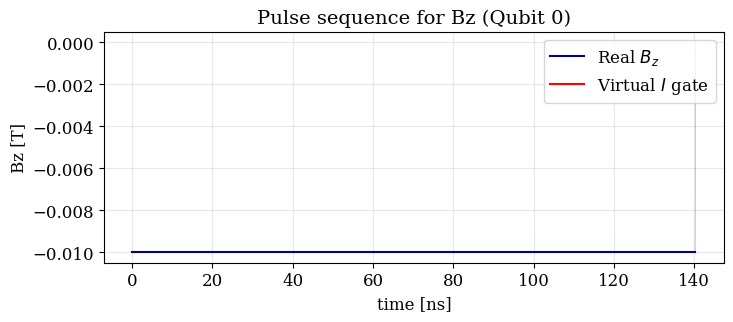

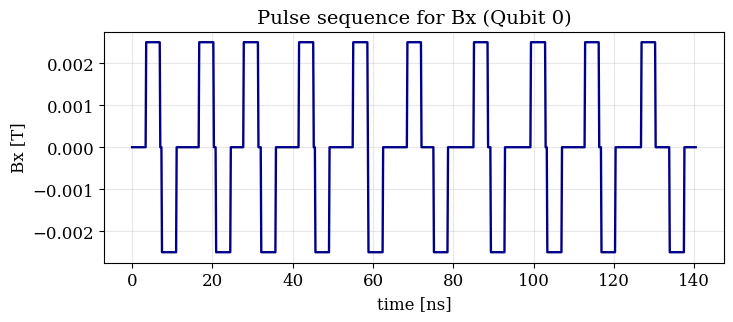

In [9]:
# Define una carpeta para guardar resultados
path_resultados = "mis_resultados_experimentales/test_01"

# La función creará la carpeta si no existe
pulse_data = extract_and_plot_pulses(
    dru_circuit, 
    plot=True, 
    verbose=1,            # Te imprimirá info sobre duración y qubits detectados
    save_path=path_resultados 
)

In [11]:
# 2 qubits con entrelazamiento:
X, y =  make_IRIS_v2(3,3)

tf_entanglement = True
N_QUBITS_SIM = 2

model = Modelo_DRU(qcircuit_2_qubit_mixed, fidelity_cost,
                        epochs = 2, n_clases = 3, n_qubits = N_QUBITS_SIM,
                        features = 3, num_layers = 4, alpha_noise = 0.0, val_prc = 0.2,
                        save_process = False, save_w_states = True,
                        entanglement = tf_entanglement )

# splita data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# get optimized parameters
paramters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=1000,
                                     N_qubits = N_QUBITS_SIM,
                                     tf_noise = False,
                                     noise_std = 0.0000,
                                     ket_dru_0 = tensor(basis(2, 0),basis(2, 0)),
                                     save_pulses= True,
                                     J = 1.52e11)

state_dru = dru_circuit.qcircuit_DRU_2_Qubit(paramters_1q,
                                             model.X_val[1],
                                             bias=bias_1q,
                                             entanglement = tf_entanglement)

Epoch: 100%|██████████| 2/2 [00:08<00:00,  4.23s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


[INFO] Datos extraídos para 2 qubits.
[INFO] Tiempo total simulación: 8.23e-08 s


C:\Users\User\AppData\Local\Temp\ipykernel_6964\1893163569.py:159: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)


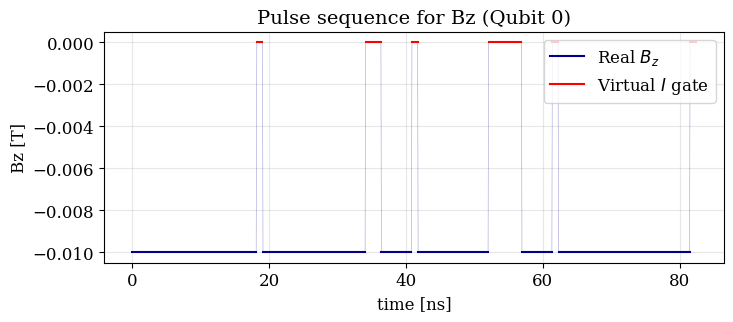

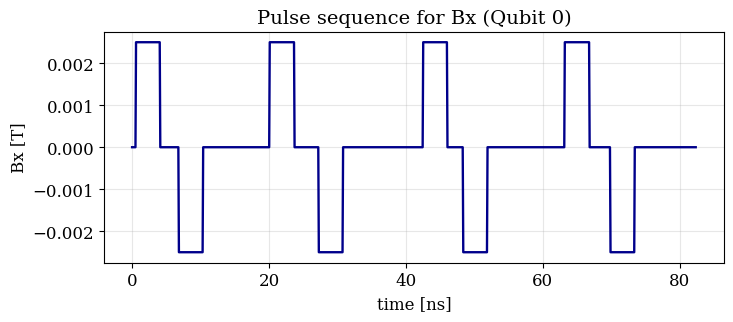

C:\Users\User\AppData\Local\Temp\ipykernel_6964\1893163569.py:159: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)


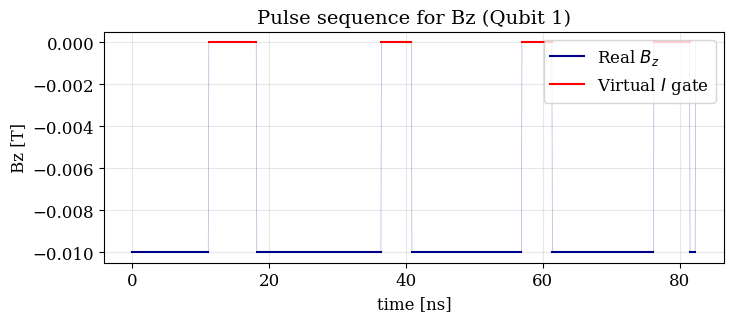

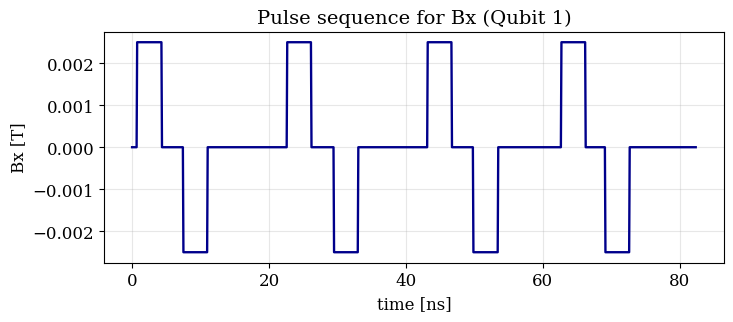

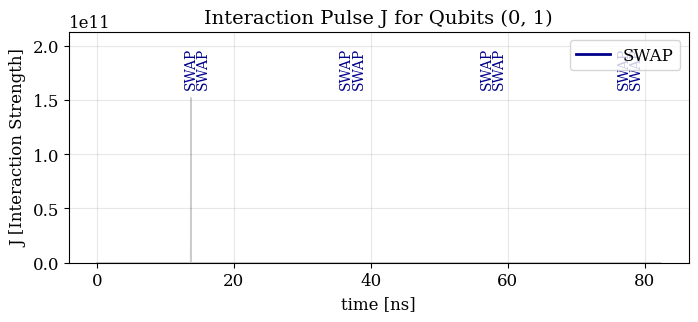

In [12]:
# Define una carpeta para guardar resultados
path_resultados = "mis_resultados_experimentales/test_02"

# La función creará la carpeta si no existe
pulse_data = extract_and_plot_pulses(
    dru_circuit, 
    plot=True, 
    verbose=1,            # Te imprimirá info sobre duración y qubits detectados
    save_path=path_resultados 
)

In [13]:
pulse_data

{'sites': {0: {'Bx': [(0, 5.251026977983963e-10, 0, 'Active'),
    (5.251026977983963e-10, 4.09509434960498e-09, 0.0025, 'Active'),
    (4.09509434960498e-09, 6.804657466184362e-09, 0, 'Active'),
    (6.804657466184362e-09, 1.0374649117990946e-08, -0.0025, 'Active'),
    (1.0374649117990946e-08, 1.3706868147325899e-08, 0, 'Active'),
    (1.3717202333686392e-08, 1.5502198159589685e-08, 0, 'Active'),
    (1.5512532345950177e-08, 1.8190026084805115e-08, 0, 'Active'),
    (1.9082523997756762e-08, 2.0102599165466264e-08, 0, 'Active'),
    (2.0102599165466264e-08, 2.3672590817272846e-08, 0.0025, 'Active'),
    (2.3672590817272846e-08, 2.719741867782225e-08, 0, 'Active'),
    (2.719741867782225e-08, 3.076741032962883e-08, -0.0025, 'Active'),
    (3.076741032962883e-08, 3.405057486508209e-08, 0, 'Active'),
    (3.6400606892134536e-08, 3.818560271803783e-08, 0, 'Active'),
    (3.8195936904398326e-08, 4.087343064325326e-08, 0, 'Active'),
    (4.176592855620491e-08, 4.245068901558077e-08, 0, 'Act

In [15]:
print(f"Pulsos extraídos. Duración total: {pulse_data['total_time']:.2e} s")
print(f"Metadata de intervalos para Qubit 0 (Bz):")
for interval in pulse_data['sites'][0]['Bz'][:5]: # Mostrar primeros 5
    print(f"  t: [{interval[0]:.2e}, {interval[1]:.2e}], Amp: {interval[2]:.2f}, Tipo: {interval[3]}")

Pulsos extraídos. Duración total: 8.23e-08 s
Metadata de intervalos para Qubit 0 (Bz):
  t: [0.00e+00, 5.25e-10], Amp: -0.01, Tipo: Active
  t: [5.25e-10, 4.10e-09], Amp: -0.01, Tipo: Active
  t: [4.10e-09, 6.80e-09], Amp: -0.01, Tipo: Active
  t: [6.80e-09, 1.04e-08], Amp: -0.01, Tipo: Active
  t: [1.04e-08, 1.37e-08], Amp: -0.01, Tipo: Active


# ----

In [19]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Constantes Físicas para la simulación
CONSTANTS = {
    'g_L': 1.0, # Asumimos 1 para conectar directo con outputs de ML
    'mu_B': 1.0,
    'J_base': 1.0
}

def get_pulse_value(t, intervals_list):
    """Busca el valor del pulso en el tiempo t dado una lista de intervalos."""
    for (t0, t1, amp, _) in intervals_list:
        if t0 <= t < t1:
            return amp
    return 0.0

def run_simulation_pipeline(pulse_data, n_qubits, n_trotter_steps=50):
    """
    Ejecuta la simulación Trotter y Exacta usando los pulsos importados.
    """
    total_time = pulse_data['total_time']
    times_trot = np.linspace(0.0, total_time, n_trotter_steps + 1)
    
    # Configurar dispositivo PennyLane
    dev = qml.device("default.qubit", wires=n_qubits)
    
    # --- Definir funciones dinámicas basadas en los datos importados ---
    
    def J_ij_at_time(i, j, t):
        # Buscar en edges (i,j) o (j,i)
        pair = (min(i,j), max(i,j))
        if pair in pulse_data['edges']:
            val = get_pulse_value(t, pulse_data['edges'][pair])
            return CONSTANTS['J_base'] * val
        return 0.0

    def B_i_at_time(i, t):
        if i in pulse_data['sites']:
            bx = get_pulse_value(t, pulse_data['sites'][i]['Bx'])
            bz = get_pulse_value(t, pulse_data['sites'][i]['Bz'])
            return np.array([bx, 0.0, bz]) # Asumimos By=0 por ahora
        return np.array([0.0, 0.0, 0.0])

    # --- Trotter Step en PennyLane ---
    def apply_trotter_step(dt_local, t_current):
        # 1. Interacciones J
        for (i, j) in pulse_data['edges'].keys():
            Jij = J_ij_at_time(i, j, t_current)
            if abs(Jij) > 1e-12:
                theta = Jij * dt_local / 2.0 
                qml.IsingXX(theta, wires=[i, j])
                qml.IsingYY(theta, wires=[i, j])
                qml.IsingZZ(theta, wires=[i, j])
        
        # 2. Campos Locales (Bx, Bz)
        for i in range(n_qubits):
            bx, by, bz = B_i_at_time(i, t_current)
            # Nota: Los signos dependen de la convención H = - B * S
            if abs(bx) > 1e-12: qml.RX(-2 * bx * dt_local, wires=i) # factor 2 por Pauli vs Spin
            if abs(bz) > 1e-12: qml.RZ(-2 * bz * dt_local, wires=i)

    @qml.qnode(dev)
    def qnode_trotter(target_time, steps):
        # Estado inicial (ejemplo: todos en |0>)
        # Si tu ML asume otro estado inicial, cámbialo aquí.
        for w in range(n_qubits):
            qml.PauliX(wires=w) # Inicia en |1> (down) como el ejemplo original

        dt = target_time / steps if steps > 0 else 0
        for k in range(steps):
            t = (k + 0.5) * dt
            apply_trotter_step(dt, t)
            
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    # --- Loop de Simulación ---
    magnetization_history = []
    
    print(f"Iniciando simulación Trotter para {n_qubits} qubits...")
    for k, t_curr in enumerate(times_trot):
        if k == 0:
            magnetization_history.append(-1.0) # Valor inicial medio
            continue
            
        res = qnode_trotter(t_curr, k)
        # Promedio de magnetización Z
        avg_mag = np.mean([float(r) for r in res])
        magnetization_history.append(avg_mag)
    
    return times_trot, magnetization_history

def plot_simulation_results(times, mag_data):
    plt.figure(figsize=(8, 4))
    plt.plot(times * 1e9, mag_data, 'o--', color='tab:red', label='Trotter Simulation')
    plt.xlabel('Tiempo [ns]')
    plt.ylabel('Magnetización Media <Z>')
    plt.title('Dinámica del Sistema bajo Pulsos Generados')
    plt.grid(True)
    plt.legend()
    plt.show()

=== PASO 1: Entrenamiento del Modelo Cuántico (Pipeline 1) ===


Epoch: 100%|██████████| 5/5 [00:20<00:00,  4.10s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(



=== PASO 2: Extracción y Formateo de Pulsos ===


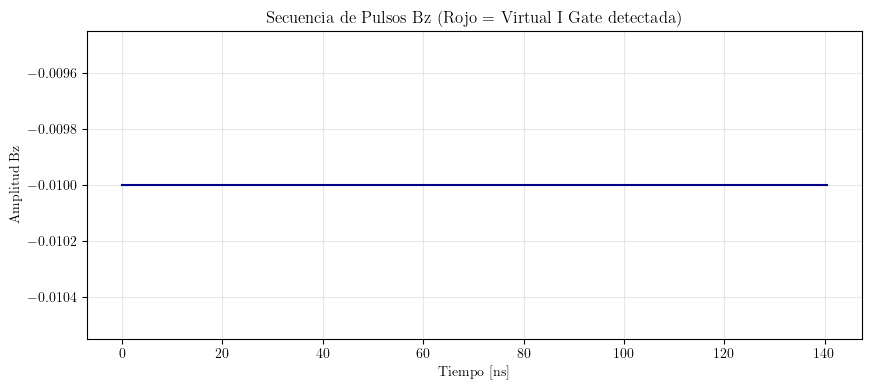

Pulsos extraídos. Duración total: 1.40e-07 s
Metadata de intervalos para Qubit 0 (Bz):
  t: [0.00e+00, 3.44e-09], Amp: -0.01, Tipo: Active
  t: [3.44e-09, 7.01e-09], Amp: -0.01, Tipo: Active
  t: [7.01e-09, 7.41e-09], Amp: -0.01, Tipo: Active
  t: [7.41e-09, 1.10e-08], Amp: -0.01, Tipo: Active
  t: [1.10e-08, 1.32e-08], Amp: -0.01, Tipo: Active

=== PASO 3: Simulación Física con Trotter (Pipeline 2) ===
Iniciando simulación Trotter para 1 qubits...


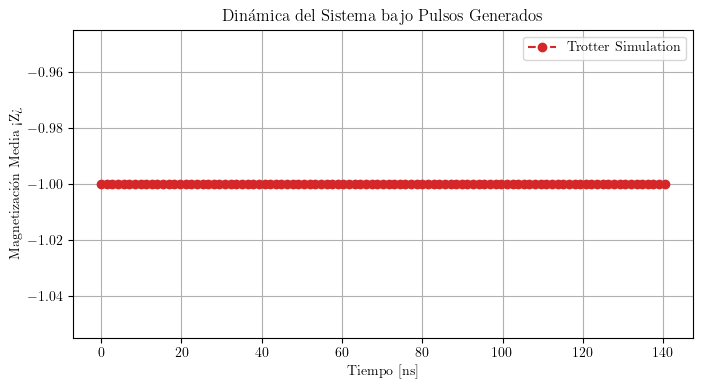


=== Integración Completada con Éxito ===


In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- Importar tus dependencias del Pipeline 1 ---
# (Asumo que estas clases existen en tu entorno o en archivos adjuntos)
# from tu_libreria import make_IRIS_v2, Modelo_DRU, qcircuit_1_qubit_mixed, CompositeGateProcessor, fidelity_cost

# --- Importar nuestros módulos nuevos ---
#from pipeline1_adapter import extract_and_plot_pulses
#from pipeline2_engine import run_simulation_pipeline, plot_simulation_results

def main():
    print("=== PASO 1: Entrenamiento del Modelo Cuántico (Pipeline 1) ===")
    
    # 1. Configuración de datos y modelo (INTACTO del original)
    X, y = make_IRIS_v2(3,3)
    
    # Nota: N_qubits = 1 en este ejemplo, pero el código soporta N > 1
    N_QUBITS_SIM = 1 
    
    model = Modelo_DRU(qcircuit_1_qubit_mixed, fidelity_cost,
                       epochs=5, n_clases=3, n_qubits=N_QUBITS_SIM,
                       features=3, num_layers=10, alpha_noise=0.0, val_prc=0.2,
                       save_process=False, save_w_states=False)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    parameters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

    # 2. Generación del Circuito y Pulsos
    dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=100,
                                         N_qubits=N_QUBITS_SIM,
                                         tf_noise=False,
                                         noise_std=0.0000, 
                                         save_pulses=True,
                                         J=1.52e11)

    # Simular paso para generar los pulsos internos
    state_dru = dru_circuit.qcircuit_DRU_1_Qubit(parameters_1q,
                                                 model.X_val[1],
                                                 bias=bias_1q)

    print("\n=== PASO 2: Extracción y Formateo de Pulsos ===")
    
    # Aquí es donde ocurre la magia de integración.
    # extract_and_plot_pulses reemplaza a plot_pulses_v33 para obtener DATOS.
    # Esta función detecta automáticamente las Virtual I Gates (gaps).
    pulse_data = extract_and_plot_pulses(dru_circuit, plot=True)
    
    print(f"Pulsos extraídos. Duración total: {pulse_data['total_time']:.2e} s")
    print(f"Metadata de intervalos para Qubit 0 (Bz):")
    for interval in pulse_data['sites'][0]['Bz'][:5]: # Mostrar primeros 5
        print(f"  t: [{interval[0]:.2e}, {interval[1]:.2e}], Amp: {interval[2]:.2f}, Tipo: {interval[3]}")

    print("\n=== PASO 3: Simulación Física con Trotter (Pipeline 2) ===")
    
    # El motor de simulación toma el diccionario de pulsos.
    # Las Virtual I Gates se manejan implícitamente: en los intervalos donde
    # el tipo es 'Virtual_I', la amplitud es 0, por lo que el Hamiltoniano
    # no aplica rotación local, 'manteniendo' el estado virtualmente.
    
    times, mag_history = run_simulation_pipeline(pulse_data, 
                                                 n_qubits=N_QUBITS_SIM, 
                                                 n_trotter_steps=100)
    
    # Graficar resultados finales
    plot_simulation_results(times, mag_history)
    
    print("\n=== Integración Completada con Éxito ===")

if __name__ == "__main__":
    # Asegúrate de tener las definiciones de las clases del Pipeline 1 disponibles
    # O ejecuta esto en el mismo script donde están definidas.
    try:
        main()
    except NameError as e:
        print(f"Error: Faltan definiciones del contexto original ({e}).")
        print("Asegúrate de pegar las clases Modelo_DRU, CompositeGateProcessor, etc., antes de main().")